In [1]:
import sys
from pathlib import Path

import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# Project path
# ============================================================

SRC_DIR = Path("../src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))


from networks import Actor, Critic
from replay_buffer import ReplayBuffer
from ddpg import DDPGAgent


# ============================================================
# Random seed
# ============================================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# Environment
# ============================================================

env = gym.make(
    "Pendulum-v1"
)

state, info = env.reset(
    seed=SEED
)

env.action_space.seed(SEED)


# ============================================================
# Environment information
# ============================================================

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

action_low = env.action_space.low
action_high = env.action_space.high


print("State:")
print(state)

print("\nObservation space:")
print(env.observation_space)

print("\nAction space:")
print(env.action_space)

print("\nstate_dim:")
print(state_dim)

print("\naction_dim:")
print(action_dim)

print("\naction_low:")
print(action_low)

print("\naction_high:")
print(action_high)

State:
[-0.14995256  0.9886932  -0.12224312]

Observation space:
Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)

Action space:
Box(-2.0, 2.0, (1,), float32)

state_dim:
3

action_dim:
1

action_low:
[-2.]

action_high:
[2.]


In [2]:
# ============================================================
# Create Actor and Critic
# ============================================================

actor = Actor(
    state_dim=state_dim,
    action_dim=action_dim,
    action_low=action_low,
    action_high=action_high,
)

critic = Critic(
    state_dim=state_dim,
    action_dim=action_dim,
)


# ============================================================
# State -> Actor -> Action
# ============================================================

state_tensor = torch.as_tensor(
    state,
    dtype=torch.float32,
).unsqueeze(0)

with torch.no_grad():

    action_tensor = actor(
        state_tensor
    )

    q_value = critic(
        state_tensor,
        action_tensor,
    )


print("State shape:")
print(state_tensor.shape)

print("\nActor action:")
print(action_tensor)

print("\nAction shape:")
print(action_tensor.shape)

print("\nCritic Q value:")
print(q_value)

print("\nQ shape:")
print(q_value.shape)

State shape:
torch.Size([1, 3])

Actor action:
tensor([[0.0309]])

Action shape:
torch.Size([1, 1])

Critic Q value:
tensor([[-0.0337]])

Q shape:
torch.Size([1, 1])


In [4]:
# ============================================================
# DDPG Training on Pendulum-v1
# ============================================================

import gymnasium as gym
import numpy as np
import torch


# ============================================================
# Hyperparameters
# ============================================================

SEED = 42

NUM_EPISODES = 200

BUFFER_CAPACITY = 100_000
LEARNING_STARTS = 1_000
BATCH_SIZE = 128

ACTOR_LR = 1e-3
CRITIC_LR = 1e-3

GAMMA = 0.99
TAU = 0.005

NOISE_STD = 0.2


# ============================================================
# Random seed
# ============================================================

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# Environment
# ============================================================

env = gym.make(
    "Pendulum-v1"
)

state, info = env.reset(
    seed=SEED
)

env.action_space.seed(SEED)


state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

action_low = env.action_space.low
action_high = env.action_space.high


# ============================================================
# Device
# ============================================================

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# Agent
# ============================================================

agent = DDPGAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    action_low=action_low,
    action_high=action_high,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    gamma=GAMMA,
    tau=TAU,
    device=device,
)


# ============================================================
# Replay Buffer
# ============================================================

replay_buffer = ReplayBuffer(
    state_dim=state_dim,
    action_dim=action_dim,
    capacity=BUFFER_CAPACITY,
)


# ============================================================
# Training statistics
# ============================================================

episode_returns = []

actor_losses = []
critic_losses = []

q_values = []
target_q_values = []

global_step = 0


# ============================================================
# Training Loop
# ============================================================

for episode in range(NUM_EPISODES):

    state, info = env.reset()

    episode_return = 0.0


    while True:

        # ----------------------------------------------------
        # 1. Select action
        #
        # a = μ(s) + exploration noise
        # ----------------------------------------------------

        action = agent.select_action(
            state,
            noise_std=NOISE_STD,
        )


        # ----------------------------------------------------
        # 2. Environment step
        # ----------------------------------------------------

        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(action)


        # ----------------------------------------------------
        # 3. Two different "done" concepts
        # ----------------------------------------------------

        # Episode 是否结束
        episode_done = (
            terminated or truncated
        )

        # TD target 是否应该停止 bootstrap
        bootstrap_done = float(
            terminated
        )


        # ----------------------------------------------------
        # 4. Store transition
        # ----------------------------------------------------

        replay_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            done=bootstrap_done,
        )


        # ----------------------------------------------------
        # 5. Update DDPG
        # ----------------------------------------------------

        if (
            global_step >= LEARNING_STARTS
            and len(replay_buffer) >= BATCH_SIZE
        ):

            info_update = agent.update(
                replay_buffer=replay_buffer,
                batch_size=BATCH_SIZE,
            )

            actor_losses.append(
                info_update["actor_loss"]
            )

            critic_losses.append(
                info_update["critic_loss"]
            )

            q_values.append(
                info_update["q_value"]
            )

            target_q_values.append(
                info_update["target_q"]
            )


        # ----------------------------------------------------
        # 6. Move to next state
        # ----------------------------------------------------

        state = next_state

        episode_return += reward

        global_step += 1


        # ----------------------------------------------------
        # 7. End episode
        # ----------------------------------------------------

        if episode_done:
            break


    episode_returns.append(
        episode_return
    )


    # ========================================================
    # Logging
    # ========================================================

    if (episode + 1) % 10 == 0:

        recent_returns = episode_returns[-10:]

        mean_return = np.mean(
            recent_returns
        )

        print(
            f"Episode {episode + 1:3d} | "
            f"Return: {episode_return:8.2f} | "
            f"10-Episode Avg: {mean_return:8.2f} | "
            f"Buffer: {len(replay_buffer):6d}"
        )


env.close()

Device: cuda
Episode  10 | Return: -1511.84 | 10-Episode Avg: -1452.59 | Buffer:   2000
Episode  20 | Return:  -756.56 | 10-Episode Avg: -1180.79 | Buffer:   4000
Episode  30 | Return:  -123.97 | 10-Episode Avg:  -314.39 | Buffer:   6000
Episode  40 | Return:  -124.00 | 10-Episode Avg:  -172.85 | Buffer:   8000
Episode  50 | Return:  -239.85 | 10-Episode Avg:  -194.26 | Buffer:  10000
Episode  60 | Return:  -125.04 | 10-Episode Avg:  -124.03 | Buffer:  12000
Episode  70 | Return:    -1.72 | 10-Episode Avg:  -155.44 | Buffer:  14000
Episode  80 | Return:  -242.59 | 10-Episode Avg:  -155.99 | Buffer:  16000
Episode  90 | Return:  -233.08 | 10-Episode Avg:  -118.83 | Buffer:  18000
Episode 100 | Return:  -115.06 | 10-Episode Avg:  -132.04 | Buffer:  20000
Episode 110 | Return:  -125.35 | 10-Episode Avg:  -177.60 | Buffer:  22000
Episode 120 | Return:  -127.08 | 10-Episode Avg:  -195.68 | Buffer:  24000
Episode 130 | Return:  -264.32 | 10-Episode Avg:  -158.08 | Buffer:  26000
Episode 140 

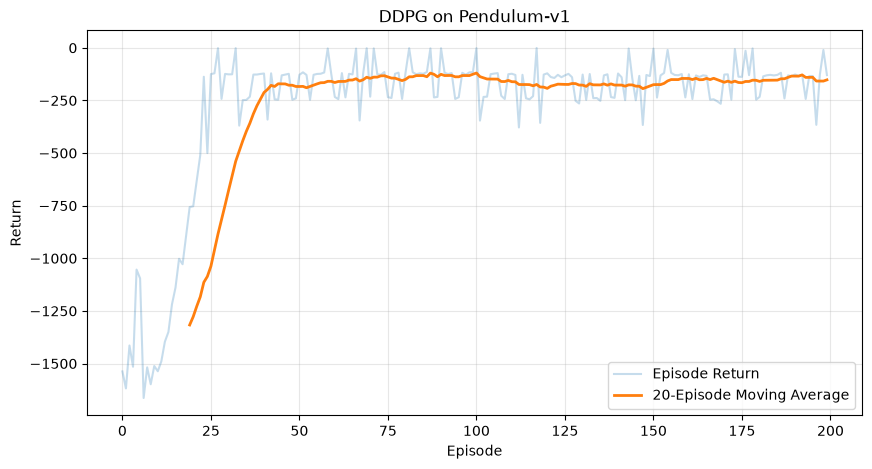

In [5]:
# ============================================================
# Training Curve
# ============================================================

returns = np.asarray(
    episode_returns,
    dtype=np.float32,
)

window = 20

moving_average = np.convolve(
    returns,
    np.ones(window) / window,
    mode="valid",
)


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    returns,
    alpha=0.25,
    label="Episode Return",
)

plt.plot(
    np.arange(
        window - 1,
        len(returns),
    ),
    moving_average,
    linewidth=2,
    label="20-Episode Moving Average",
)

plt.xlabel("Episode")
plt.ylabel("Return")

plt.title(
    "DDPG on Pendulum-v1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [8]:
# ============================================================
# Save DDPG Checkpoint
# ============================================================

from pathlib import Path
import torch


CHECKPOINT_DIR = Path("../checkpoints")

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. Save Actor Only
#
# 用于：
#   evaluation / inference / deployment
# ============================================================

actor_path = (
    CHECKPOINT_DIR
    / "ddpg_actor.pth"
)

torch.save(
    agent.actor.state_dict(),
    actor_path,
)


# ============================================================
# 2. Save Full Checkpoint
#
# 用于：
#   resume training
# ============================================================

checkpoint_path = (
    CHECKPOINT_DIR
    / "ddpg_pendulum.pth"
)

checkpoint = {

    # --------------------------------------------------------
    # Networks
    # --------------------------------------------------------

    "actor":
        agent.actor.state_dict(),

    "critic":
        agent.critic.state_dict(),

    "actor_target":
        agent.actor_target.state_dict(),

    "critic_target":
        agent.critic_target.state_dict(),


    # --------------------------------------------------------
    # Optimizers
    # --------------------------------------------------------

    "actor_optimizer":
        agent.actor_optimizer.state_dict(),

    "critic_optimizer":
        agent.critic_optimizer.state_dict(),


    # --------------------------------------------------------
    # Training state
    # --------------------------------------------------------

    "global_step":
        global_step,

    "episode_returns":
        episode_returns,


    # --------------------------------------------------------
    # Environment / model configuration
    # --------------------------------------------------------

    "state_dim":
        state_dim,

    "action_dim":
        action_dim,

    "action_low":
        action_low,

    "action_high":
        action_high,


    # --------------------------------------------------------
    # Hyperparameters
    # --------------------------------------------------------

    "actor_lr":
        ACTOR_LR,

    "critic_lr":
        CRITIC_LR,

    "gamma":
        GAMMA,

    "tau":
        TAU,

    "noise_std":
        NOISE_STD,

    "seed":
        SEED,
}


torch.save(
    checkpoint,
    checkpoint_path,
)


print(
    f"Actor saved to:\n"
    f"{actor_path.resolve()}"
)

print()

print(
    f"Full checkpoint saved to:\n"
    f"{checkpoint_path.resolve()}"
)

Actor saved to:
/workspace/YiFan/llm_agent/repos/RL-beginner/task-08-sac/checkpoints/ddpg_actor.pth

Full checkpoint saved to:
/workspace/YiFan/llm_agent/repos/RL-beginner/task-08-sac/checkpoints/ddpg_pendulum.pth


In [9]:
# ============================================================
# Load Trained DDPG Actor and Evaluate
# ============================================================

import gymnasium as gym
import numpy as np
import torch

from ddpg import DDPGAgent


# ============================================================
# Device
# ============================================================

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# Environment
# ============================================================

eval_env = gym.make(
    "Pendulum-v1"
)

state_dim = (
    eval_env.observation_space.shape[0]
)

action_dim = (
    eval_env.action_space.shape[0]
)

action_low = (
    eval_env.action_space.low
)

action_high = (
    eval_env.action_space.high
)


# ============================================================
# Create a NEW agent
#
# 注意：
# 这是一个全新的随机初始化 Agent
# ============================================================

loaded_agent = DDPGAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    action_low=action_low,
    action_high=action_high,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    gamma=GAMMA,
    tau=TAU,
    device=device,
)


# ============================================================
# Load trained Actor
# ============================================================

actor_path = (
    Path("../checkpoints")
    / "ddpg_actor.pth"
)

actor_state_dict = torch.load(
    actor_path,
    map_location=device,
)

loaded_agent.actor.load_state_dict(
    actor_state_dict
)

loaded_agent.actor.eval()


print(
    "Actor loaded successfully."
)


# ============================================================
# Deterministic Evaluation
# ============================================================

EVAL_EPISODES = 20

eval_returns_loaded = []


for episode in range(EVAL_EPISODES):

    state, info = eval_env.reset(
        seed=SEED + 1000 + episode
    )

    episode_return = 0.0


    while True:

        # ----------------------------------------------------
        # No exploration noise
        # ----------------------------------------------------

        action = loaded_agent.select_action(
            state,
            noise_std=0.0,
        )


        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = eval_env.step(
            action
        )


        episode_return += reward

        state = next_state


        if terminated or truncated:
            break


    eval_returns_loaded.append(
        episode_return
    )


eval_env.close()


eval_returns_loaded = np.asarray(
    eval_returns_loaded,
    dtype=np.float32,
)


print()

print(
    f"Loaded Model Evaluation Return: "
    f"{eval_returns_loaded.mean():.2f} "
    f"± {eval_returns_loaded.std():.2f}"
)

print(
    f"Best Episode: "
    f"{eval_returns_loaded.max():.2f}"
)

print(
    f"Worst Episode: "
    f"{eval_returns_loaded.min():.2f}"
)

Actor loaded successfully.

Loaded Model Evaluation Return: -169.46 ± 101.80
Best Episode: -3.31
Worst Episode: -337.50


In [10]:
# ============================================================
# Analyze One Deterministic Evaluation Trajectory
# ============================================================

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


eval_env = gym.make(
    "Pendulum-v1"
)

state, info = eval_env.reset(
    seed=SEED + 2000
)


angles = []
angular_velocities = []
actions = []
rewards = []

episode_return = 0.0


while True:

    # ========================================================
    # Recover physical state
    #
    # state = [cos(theta), sin(theta), theta_dot]
    # ========================================================

    cos_theta = state[0]
    sin_theta = state[1]
    theta_dot = state[2]

    theta = np.arctan2(
        sin_theta,
        cos_theta,
    )


    # ========================================================
    # Deterministic policy
    # ========================================================

    action = loaded_agent.select_action(
        state,
        noise_std=0.0,
    )


    # ========================================================
    # Environment step
    # ========================================================

    (
        next_state,
        reward,
        terminated,
        truncated,
        info,
    ) = eval_env.step(
        action
    )


    # ========================================================
    # Record trajectory
    # ========================================================

    angles.append(theta)

    angular_velocities.append(
        theta_dot
    )

    actions.append(
        action[0]
    )

    rewards.append(
        reward
    )

    episode_return += reward

    state = next_state


    if terminated or truncated:
        break


eval_env.close()


angles = np.asarray(angles)
angular_velocities = np.asarray(
    angular_velocities
)
actions = np.asarray(actions)
rewards = np.asarray(rewards)


print(
    f"Episode Return: "
    f"{episode_return:.2f}"
)

print(
    f"Final Angle: "
    f"{angles[-1]:.4f} rad"
)

print(
    f"Final Angular Velocity: "
    f"{angular_velocities[-1]:.4f} rad/s"
)

Episode Return: -3.89
Final Angle: 0.1265 rad
Final Angular Velocity: 0.1429 rad/s


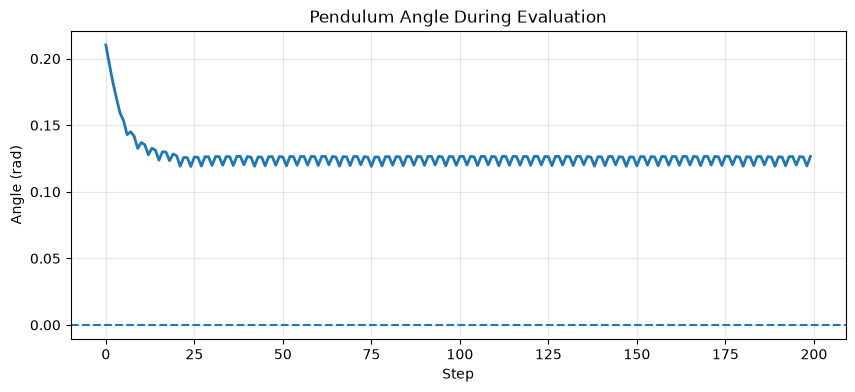

In [11]:
plt.figure(
    figsize=(10, 4)
)

plt.plot(
    angles,
    linewidth=2,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Step")
plt.ylabel("Angle (rad)")

plt.title(
    "Pendulum Angle During Evaluation"
)

plt.grid(
    alpha=0.3
)

plt.show()

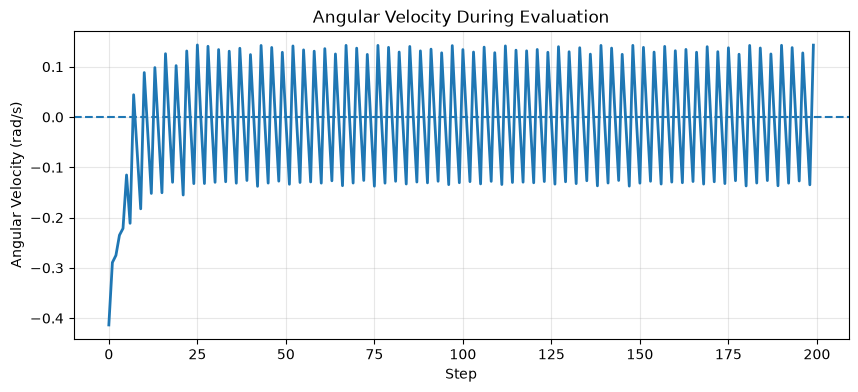

In [12]:
plt.figure(
    figsize=(10, 4)
)

plt.plot(
    angular_velocities,
    linewidth=2,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Step")
plt.ylabel("Angular Velocity (rad/s)")

plt.title(
    "Angular Velocity During Evaluation"
)

plt.grid(
    alpha=0.3
)

plt.show()

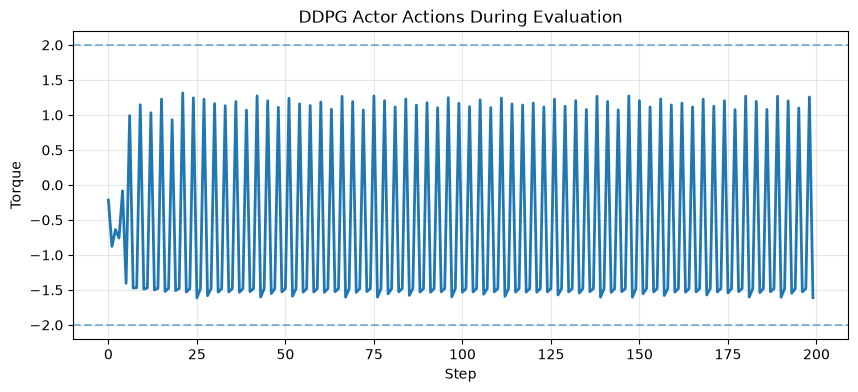

In [13]:
plt.figure(
    figsize=(10, 4)
)

plt.plot(
    actions,
    linewidth=2,
)

plt.axhline(
    y=2,
    linestyle="--",
    alpha=0.5,
)

plt.axhline(
    y=-2,
    linestyle="--",
    alpha=0.5,
)

plt.xlabel("Step")
plt.ylabel("Torque")

plt.title(
    "DDPG Actor Actions During Evaluation"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [2]:
# ============================================================
# Train TD3 on Pendulum-v1
# ============================================================

import gymnasium as gym
import numpy as np
import torch

from td3 import TD3Agent
from replay_buffer import ReplayBuffer


# ============================================================
# Hyperparameters
# ============================================================

SEED = 42

NUM_EPISODES = 200

BUFFER_CAPACITY = 100_000
LEARNING_STARTS = 1_000
BATCH_SIZE = 128

ACTOR_LR = 1e-3
CRITIC_LR = 1e-3

GAMMA = 0.99
TAU = 0.005

# 与环境交互时的 exploration noise
EXPLORATION_NOISE = 0.2

# TD3 特有参数
POLICY_NOISE = 0.2
NOISE_CLIP = 0.5
POLICY_DELAY = 2


# ============================================================
# Seed
# ============================================================

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# Environment
# ============================================================

env_td3 = gym.make(
    "Pendulum-v1"
)

state, info = env_td3.reset(
    seed=SEED
)

env_td3.action_space.seed(SEED)


state_dim = env_td3.observation_space.shape[0]
action_dim = env_td3.action_space.shape[0]

action_low = env_td3.action_space.low
action_high = env_td3.action_space.high


device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# TD3 Agent
# ============================================================

td3_agent = TD3Agent(
    state_dim=state_dim,
    action_dim=action_dim,
    action_low=action_low,
    action_high=action_high,

    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,

    gamma=GAMMA,
    tau=TAU,

    policy_noise=POLICY_NOISE,
    noise_clip=NOISE_CLIP,
    policy_delay=POLICY_DELAY,

    device=device,
)


# ============================================================
# Replay Buffer
# ============================================================

td3_buffer = ReplayBuffer(
    state_dim=state_dim,
    action_dim=action_dim,
    capacity=BUFFER_CAPACITY,
)


# ============================================================
# Logs
# ============================================================

td3_returns = []

td3_actor_losses = []
td3_critic1_losses = []
td3_critic2_losses = []

td3_global_step = 0


# ============================================================
# Training
# ============================================================

for episode in range(NUM_EPISODES):

    state, info = env_td3.reset()

    episode_return = 0.0


    while True:

        # ----------------------------------------------------
        # Deterministic Actor + exploration noise
        # ----------------------------------------------------

        action = td3_agent.select_action(
            state,
            noise_std=EXPLORATION_NOISE,
        )


        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env_td3.step(action)


        episode_done = (
            terminated or truncated
        )

        bootstrap_done = float(
            terminated
        )


        td3_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            done=bootstrap_done,
        )


        # ----------------------------------------------------
        # Learn
        # ----------------------------------------------------

        if (
            td3_global_step >= LEARNING_STARTS
            and len(td3_buffer) >= BATCH_SIZE
        ):

            update_info = td3_agent.update(
                replay_buffer=td3_buffer,
                batch_size=BATCH_SIZE,
            )


            td3_critic1_losses.append(
                update_info["critic1_loss"]
            )

            td3_critic2_losses.append(
                update_info["critic2_loss"]
            )


            # Actor 并不是每一步都会更新
            if (
                update_info["actor_loss"]
                is not None
            ):

                td3_actor_losses.append(
                    update_info["actor_loss"]
                )


        state = next_state

        episode_return += reward

        td3_global_step += 1


        if episode_done:
            break


    td3_returns.append(
        episode_return
    )


    if (episode + 1) % 10 == 0:

        mean_return = np.mean(
            td3_returns[-10:]
        )

        print(
            f"Episode {episode + 1:3d} | "
            f"Return: {episode_return:8.2f} | "
            f"10-Episode Avg: {mean_return:8.2f} | "
            f"Buffer: {len(td3_buffer):6d}"
        )


env_td3.close()

Episode  10 | Return: -1682.58 | 10-Episode Avg: -1517.12 | Buffer:   2000
Episode  20 | Return: -1203.18 | 10-Episode Avg: -1469.88 | Buffer:   4000
Episode  30 | Return:  -759.68 | 10-Episode Avg: -1009.92 | Buffer:   6000
Episode  40 | Return:  -254.41 | 10-Episode Avg:  -492.76 | Buffer:   8000
Episode  50 | Return:  -243.97 | 10-Episode Avg:  -209.82 | Buffer:  10000
Episode  60 | Return:  -128.39 | 10-Episode Avg:  -136.89 | Buffer:  12000
Episode  70 | Return:    -2.95 | 10-Episode Avg:  -161.13 | Buffer:  14000
Episode  80 | Return:  -260.11 | 10-Episode Avg:  -161.25 | Buffer:  16000
Episode  90 | Return:  -234.97 | 10-Episode Avg:  -120.90 | Buffer:  18000
Episode 100 | Return:  -116.14 | 10-Episode Avg:  -134.82 | Buffer:  20000
Episode 110 | Return:  -119.71 | 10-Episode Avg:  -179.85 | Buffer:  22000
Episode 120 | Return:  -117.02 | 10-Episode Avg:  -192.66 | Buffer:  24000
Episode 130 | Return:  -250.79 | 10-Episode Avg:  -147.95 | Buffer:  26000
Episode 140 | Return:  -2

In [3]:
# ============================================================
# Train SAC on Pendulum-v1
# ============================================================

import gymnasium as gym
import numpy as np
import torch

from sac import SACAgent
from replay_buffer import ReplayBuffer


# ============================================================
# Hyperparameters
# ============================================================

SEED = 42

NUM_EPISODES = 200

BUFFER_CAPACITY = 100_000
LEARNING_STARTS = 1_000
BATCH_SIZE = 128

SAC_ACTOR_LR = 3e-4
SAC_CRITIC_LR = 1e-3
ALPHA_LR = 1e-3

GAMMA = 0.99
TAU = 0.005

INIT_ALPHA = 0.2


# ============================================================
# Seed
# ============================================================

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# Environment
# ============================================================

env_sac = gym.make(
    "Pendulum-v1"
)

state, info = env_sac.reset(
    seed=SEED
)

env_sac.action_space.seed(SEED)


state_dim = env_sac.observation_space.shape[0]
action_dim = env_sac.action_space.shape[0]

action_low = env_sac.action_space.low
action_high = env_sac.action_space.high


device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# SAC Agent
# ============================================================

sac_agent = SACAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    action_low=action_low,
    action_high=action_high,

    actor_lr=SAC_ACTOR_LR,
    critic_lr=SAC_CRITIC_LR,
    alpha_lr=ALPHA_LR,

    gamma=GAMMA,
    tau=TAU,

    init_alpha=INIT_ALPHA,
    autotune=True,

    device=device,
)


# ============================================================
# Replay Buffer
# ============================================================

sac_buffer = ReplayBuffer(
    state_dim=state_dim,
    action_dim=action_dim,
    capacity=BUFFER_CAPACITY,
)


# ============================================================
# Logs
# ============================================================

sac_returns = []

sac_actor_losses = []
sac_critic1_losses = []
sac_critic2_losses = []

sac_alphas = []
sac_log_probs = []

sac_global_step = 0


# ============================================================
# Training
# ============================================================

for episode in range(NUM_EPISODES):

    state, info = env_sac.reset()

    episode_return = 0.0


    while True:

        # ----------------------------------------------------
        # SAC stochastic policy
        #
        # a ~ π(a|s)
        # ----------------------------------------------------

        action = sac_agent.select_action(
            state,
            deterministic=False,
        )


        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env_sac.step(action)


        episode_done = (
            terminated or truncated
        )

        bootstrap_done = float(
            terminated
        )


        sac_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            done=bootstrap_done,
        )


        # ----------------------------------------------------
        # Learn
        # ----------------------------------------------------

        if (
            sac_global_step >= LEARNING_STARTS
            and len(sac_buffer) >= BATCH_SIZE
        ):

            update_info = sac_agent.update(
                replay_buffer=sac_buffer,
                batch_size=BATCH_SIZE,
            )


            sac_actor_losses.append(
                update_info["actor_loss"]
            )

            sac_critic1_losses.append(
                update_info["critic1_loss"]
            )

            sac_critic2_losses.append(
                update_info["critic2_loss"]
            )

            sac_alphas.append(
                update_info["alpha"]
            )

            sac_log_probs.append(
                update_info["log_prob"]
            )


        state = next_state

        episode_return += reward

        sac_global_step += 1


        if episode_done:
            break


    sac_returns.append(
        episode_return
    )


    if (episode + 1) % 10 == 0:

        mean_return = np.mean(
            sac_returns[-10:]
        )


        if len(sac_alphas) > 0:

            current_alpha = (
                sac_alphas[-1]
            )

        else:

            current_alpha = (
                INIT_ALPHA
            )


        print(
            f"Episode {episode + 1:3d} | "
            f"Return: {episode_return:8.2f} | "
            f"10-Episode Avg: {mean_return:8.2f} | "
            f"Alpha: {current_alpha:.4f}"
        )


env_sac.close()

Episode  10 | Return: -1612.73 | 10-Episode Avg: -1447.97 | Alpha: 0.0933
Episode  20 | Return:  -516.58 | 10-Episode Avg: -1056.57 | Alpha: 0.0639
Episode  30 | Return:  -124.11 | 10-Episode Avg:  -211.49 | Alpha: 0.0627
Episode  40 | Return:  -123.76 | 10-Episode Avg:  -269.54 | Alpha: 0.0647
Episode  50 | Return:  -235.42 | 10-Episode Avg:  -158.77 | Alpha: 0.0599
Episode  60 | Return:  -125.02 | 10-Episode Avg:  -123.95 | Alpha: 0.0362
Episode  70 | Return:    -0.59 | 10-Episode Avg:  -145.16 | Alpha: 0.0319
Episode  80 | Return:  -245.41 | 10-Episode Avg:  -155.87 | Alpha: 0.0451
Episode  90 | Return:  -237.36 | 10-Episode Avg:  -121.58 | Alpha: 0.0423
Episode 100 | Return:  -115.92 | 10-Episode Avg:  -139.39 | Alpha: 0.0419
Episode 110 | Return:  -131.59 | 10-Episode Avg:  -172.30 | Alpha: 0.0344
Episode 120 | Return:  -124.68 | 10-Episode Avg:  -173.68 | Alpha: 0.0379
Episode 130 | Return:  -254.65 | 10-Episode Avg:  -155.48 | Alpha: 0.0457
Episode 140 | Return:  -239.20 | 10-Ep

In [5]:
# ============================================================
# Save TD3 Checkpoint
# ============================================================

from pathlib import Path
import torch


CHECKPOINT_DIR = Path("../checkpoints")

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. Actor only
# ============================================================

td3_actor_path = (
    CHECKPOINT_DIR
    / "td3_actor.pth"
)

torch.save(
    td3_agent.actor.state_dict(),
    td3_actor_path,
)


# ============================================================
# 2. Full checkpoint
# ============================================================

td3_checkpoint_path = (
    CHECKPOINT_DIR
    / "td3_pendulum.pth"
)

torch.save(
    {
        # Networks
        "actor":
            td3_agent.actor.state_dict(),

        "actor_target":
            td3_agent.actor_target.state_dict(),

        "critic1":
            td3_agent.critic1.state_dict(),

        "critic2":
            td3_agent.critic2.state_dict(),

        "critic1_target":
            td3_agent.critic1_target.state_dict(),

        "critic2_target":
            td3_agent.critic2_target.state_dict(),


        # Optimizers
        "actor_optimizer":
            td3_agent.actor_optimizer.state_dict(),

        "critic1_optimizer":
            td3_agent.critic1_optimizer.state_dict(),

        "critic2_optimizer":
            td3_agent.critic2_optimizer.state_dict(),


        # Training state
        "global_step":
            td3_global_step,

        "update_step":
            td3_agent.update_step,

        "episode_returns":
            td3_returns,


        # Environment
        "state_dim":
            state_dim,

        "action_dim":
            action_dim,

        "action_low":
            action_low,

        "action_high":
            action_high,


        # Hyperparameters
        "actor_lr":
            ACTOR_LR,

        "critic_lr":
            CRITIC_LR,

        "gamma":
            GAMMA,

        "tau":
            TAU,

        "exploration_noise":
            EXPLORATION_NOISE,

        "policy_noise":
            POLICY_NOISE,

        "noise_clip":
            NOISE_CLIP,

        "policy_delay":
            POLICY_DELAY,

        "seed":
            SEED,
    },
    td3_checkpoint_path,
)


print(
    f"TD3 Actor saved to:\n"
    f"{td3_actor_path.resolve()}"
)

print()

print(
    f"TD3 checkpoint saved to:\n"
    f"{td3_checkpoint_path.resolve()}"
)

TD3 Actor saved to:
/workspace/YiFan/llm_agent/repos/RL-beginner/task-08-sac/checkpoints/td3_actor.pth

TD3 checkpoint saved to:
/workspace/YiFan/llm_agent/repos/RL-beginner/task-08-sac/checkpoints/td3_pendulum.pth


In [6]:
# ============================================================
# Save SAC Checkpoint
# ============================================================

from pathlib import Path
import torch


CHECKPOINT_DIR = Path("../checkpoints")

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. Actor only
# ============================================================

sac_actor_path = (
    CHECKPOINT_DIR
    / "sac_actor.pth"
)

torch.save(
    sac_agent.actor.state_dict(),
    sac_actor_path,
)


# ============================================================
# 2. Full checkpoint
# ============================================================

sac_checkpoint = {

    # Networks
    "actor":
        sac_agent.actor.state_dict(),

    "critic1":
        sac_agent.critic1.state_dict(),

    "critic2":
        sac_agent.critic2.state_dict(),

    "critic1_target":
        sac_agent.critic1_target.state_dict(),

    "critic2_target":
        sac_agent.critic2_target.state_dict(),


    # Optimizers
    "actor_optimizer":
        sac_agent.actor_optimizer.state_dict(),

    "critic1_optimizer":
        sac_agent.critic1_optimizer.state_dict(),

    "critic2_optimizer":
        sac_agent.critic2_optimizer.state_dict(),


    # Training state
    "global_step":
        sac_global_step,

    "episode_returns":
        sac_returns,


    # Environment
    "state_dim":
        state_dim,

    "action_dim":
        action_dim,

    "action_low":
        action_low,

    "action_high":
        action_high,


    # Hyperparameters
    "actor_lr":
        SAC_ACTOR_LR,

    "critic_lr":
        SAC_CRITIC_LR,

    "alpha_lr":
        ALPHA_LR,

    "gamma":
        GAMMA,

    "tau":
        TAU,

    "init_alpha":
        INIT_ALPHA,

    "autotune":
        sac_agent.autotune,

    "seed":
        SEED,
}


# ============================================================
# Automatic entropy tuning state
# ============================================================

if sac_agent.autotune:

    sac_checkpoint[
        "log_alpha"
    ] = (
        sac_agent.log_alpha
        .detach()
        .cpu()
    )

    sac_checkpoint[
        "alpha_optimizer"
    ] = (
        sac_agent
        .alpha_optimizer
        .state_dict()
    )


sac_checkpoint_path = (
    CHECKPOINT_DIR
    / "sac_pendulum.pth"
)


torch.save(
    sac_checkpoint,
    sac_checkpoint_path,
)


print(
    f"SAC Actor saved to:\n"
    f"{sac_actor_path.resolve()}"
)

print()

print(
    f"SAC checkpoint saved to:\n"
    f"{sac_checkpoint_path.resolve()}"
)

SAC Actor saved to:
/workspace/YiFan/llm_agent/repos/RL-beginner/task-08-sac/checkpoints/sac_actor.pth

SAC checkpoint saved to:
/workspace/YiFan/llm_agent/repos/RL-beginner/task-08-sac/checkpoints/sac_pendulum.pth


DDPG episodes: 200
TD3  episodes: 200
SAC   episodes: 200


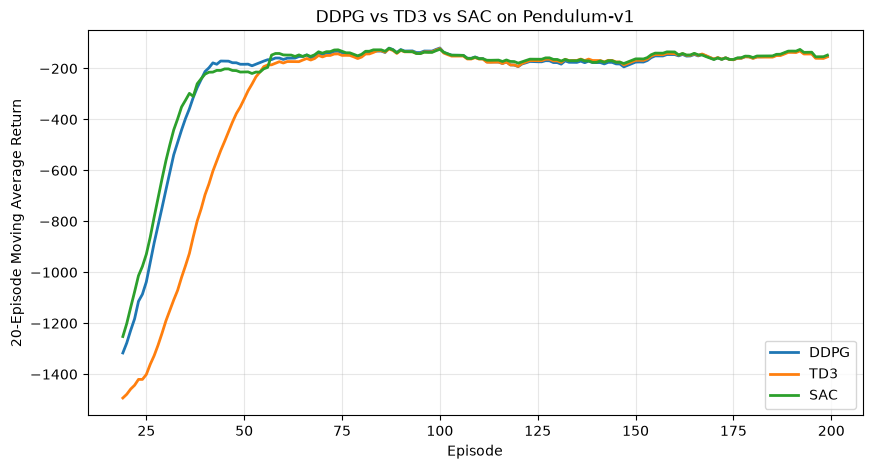

In [7]:
# ============================================================
# Load DDPG / TD3 / SAC Training Results
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch


CHECKPOINT_DIR = Path("../checkpoints")

ddpg_path = CHECKPOINT_DIR / "ddpg_pendulum.pth"
td3_path = CHECKPOINT_DIR / "td3_pendulum.pth"
sac_path = CHECKPOINT_DIR / "sac_pendulum.pth"


# ============================================================
# Load checkpoints
# ============================================================

ddpg_ckpt = torch.load(
    ddpg_path,
    map_location="cpu",
    weights_only=False,
)

td3_ckpt = torch.load(
    td3_path,
    map_location="cpu",
    weights_only=False,
)

sac_ckpt = torch.load(
    sac_path,
    map_location="cpu",
    weights_only=False,
)


# ============================================================
# Extract returns
# ============================================================

ddpg_returns = np.asarray(
    ddpg_ckpt["episode_returns"],
    dtype=np.float32,
)

td3_returns = np.asarray(
    td3_ckpt["episode_returns"],
    dtype=np.float32,
)

sac_returns = np.asarray(
    sac_ckpt["episode_returns"],
    dtype=np.float32,
)


print("DDPG episodes:", len(ddpg_returns))
print("TD3  episodes:", len(td3_returns))
print("SAC   episodes:", len(sac_returns))

# ============================================================
# Moving Average
# ============================================================

WINDOW = 20


def moving_average(
    values,
    window=20,
):

    values = np.asarray(
        values,
        dtype=np.float32,
    )

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid",
    )


ddpg_ma = moving_average(
    ddpg_returns,
    WINDOW,
)

td3_ma = moving_average(
    td3_returns,
    WINDOW,
)

sac_ma = moving_average(
    sac_returns,
    WINDOW,
)


ddpg_x = np.arange(
    WINDOW - 1,
    len(ddpg_returns),
)

td3_x = np.arange(
    WINDOW - 1,
    len(td3_returns),
)

sac_x = np.arange(
    WINDOW - 1,
    len(sac_returns),
)


# ============================================================
# Plot
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    ddpg_x,
    ddpg_ma,
    linewidth=2,
    label="DDPG",
)

plt.plot(
    td3_x,
    td3_ma,
    linewidth=2,
    label="TD3",
)

plt.plot(
    sac_x,
    sac_ma,
    linewidth=2,
    label="SAC",
)

plt.xlabel("Episode")

plt.ylabel(
    "20-Episode Moving Average Return"
)

plt.title(
    "DDPG vs TD3 vs SAC on Pendulum-v1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [ ]:
# ============================================================
# Restore DDPG / TD3 / SAC Agents
# ============================================================

import torch

from ddpg import DDPGAgent
from td3 import TD3Agent
from sac import SACAgent


device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# DDPG
# ============================================================

ddpg_agent_loaded = DDPGAgent(
    state_dim=ddpg_ckpt["state_dim"],
    action_dim=ddpg_ckpt["action_dim"],
    action_low=ddpg_ckpt["action_low"],
    action_high=ddpg_ckpt["action_high"],
    actor_lr=ddpg_ckpt["actor_lr"],
    critic_lr=ddpg_ckpt["critic_lr"],
    gamma=ddpg_ckpt["gamma"],
    tau=ddpg_ckpt["tau"],
    device=device,
)

ddpg_agent_loaded.actor.load_state_dict(
    ddpg_ckpt["actor"]
)

ddpg_agent_loaded.actor.eval()


# ============================================================
# TD3
# ============================================================

td3_agent_loaded = TD3Agent(
    state_dim=td3_ckpt["state_dim"],
    action_dim=td3_ckpt["action_dim"],
    action_low=td3_ckpt["action_low"],
    action_high=td3_ckpt["action_high"],
    actor_lr=td3_ckpt["actor_lr"],
    critic_lr=td3_ckpt["critic_lr"],
    gamma=td3_ckpt["gamma"],
    tau=td3_ckpt["tau"],
    policy_noise=td3_ckpt["policy_noise"],
    noise_clip=td3_ckpt["noise_clip"],
    policy_delay=td3_ckpt["policy_delay"],
    device=device,
)

td3_agent_loaded.actor.load_state_dict(
    td3_ckpt["actor"]
)

td3_agent_loaded.actor.eval()


# ============================================================
# SAC
# ============================================================

sac_agent_loaded = SACAgent(
    state_dim=sac_ckpt["state_dim"],
    action_dim=sac_ckpt["action_dim"],
    action_low=sac_ckpt["action_low"],
    action_high=sac_ckpt["action_high"],
    actor_lr=sac_ckpt["actor_lr"],
    critic_lr=sac_ckpt["critic_lr"],
    alpha_lr=sac_ckpt["alpha_lr"],
    gamma=sac_ckpt["gamma"],
    tau=sac_ckpt["tau"],
    init_alpha=sac_ckpt["init_alpha"],
    autotune=sac_ckpt["autotune"],
    device=device,
)

sac_agent_loaded.actor.load_state_dict(
    sac_ckpt["actor"]
)

sac_agent_loaded.actor.eval()


print(
    "DDPG / TD3 / SAC actors "
    "loaded successfully."
)

# ============================================================
# Unified Deterministic Evaluation
# ============================================================


EVAL_EPISODES = 30
EVAL_SEED_BASE = 1000


def evaluate_agent(
    agent,
    algorithm,
    num_episodes=30,
):

    env = gym.make(
        "Pendulum-v1"
    )

    returns = []


    for episode in range(
        num_episodes
    ):

        state, info = env.reset(
            seed=EVAL_SEED_BASE + episode
        )

        episode_return = 0.0


        while True:

            # =================================================
            # Deterministic policy
            # =================================================

            if algorithm in [
                "DDPG",
                "TD3",
            ]:

                action = agent.select_action(
                    state,
                    noise_std=0.0,
                )

            elif algorithm == "SAC":

                action = agent.select_action(
                    state,
                    deterministic=True,
                )

            else:

                raise ValueError(
                    f"Unknown algorithm: {algorithm}"
                )


            (
                next_state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)


            episode_return += reward

            state = next_state


            if terminated or truncated:
                break


        returns.append(
            episode_return
        )


    env.close()


    return np.asarray(
        returns,
        dtype=np.float32,
    )


# ============================================================
# Evaluation
# ============================================================

ddpg_eval = evaluate_agent(
    ddpg_agent_loaded,
    "DDPG",
    EVAL_EPISODES,
)

td3_eval = evaluate_agent(
    td3_agent_loaded,
    "TD3",
    EVAL_EPISODES,
)

sac_eval = evaluate_agent(
    sac_agent_loaded,
    "SAC",
    EVAL_EPISODES,
)


# ============================================================
# Results
# ============================================================

def print_result(
    name,
    returns,
):

    print(
        f"{name:5s} | "
        f"Mean: {returns.mean():8.2f} ± "
        f"{returns.std():7.2f} | "
        f"Best: {returns.max():8.2f} | "
        f"Worst: {returns.min():8.2f}"
    )


print(
    "===== Deterministic Evaluation ====="
)

print_result(
    "DDPG",
    ddpg_eval,
)

print_result(
    "TD3",
    td3_eval,
)

print_result(
    "SAC",
    sac_eval,
)

Device: cuda
DDPG / TD3 / SAC actors loaded successfully.
===== Deterministic Evaluation =====
DDPG  | Mean:  -152.58 ±   81.85 | Best:    -3.73 | Worst:  -350.82
TD3   | Mean:  -158.87 ±   80.06 | Best:   -14.61 | Worst:  -353.69
SAC   | Mean:  -147.21 ±   81.10 | Best:    -0.98 | Worst:  -343.88


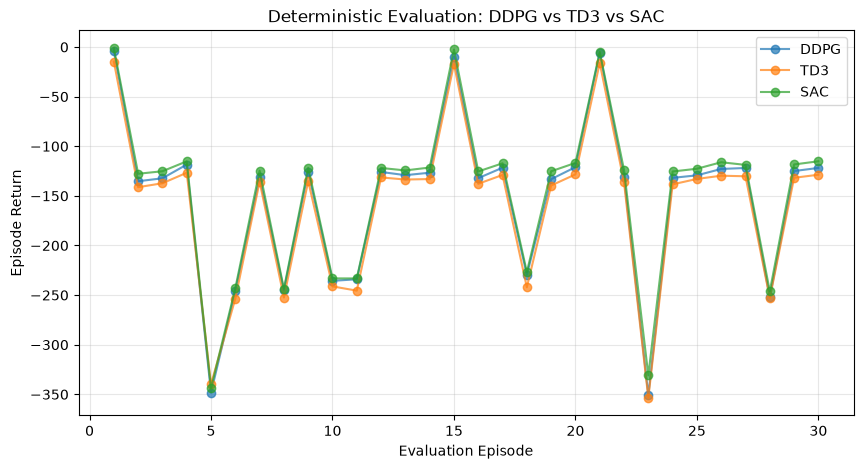

In [10]:
# ============================================================
# Evaluation Return Distribution
# ============================================================

plt.figure(
    figsize=(10, 5)
)

episodes = np.arange(
    1,
    EVAL_EPISODES + 1,
)

plt.plot(
    episodes,
    ddpg_eval,
    marker="o",
    alpha=0.7,
    label="DDPG",
)

plt.plot(
    episodes,
    td3_eval,
    marker="o",
    alpha=0.7,
    label="TD3",
)

plt.plot(
    episodes,
    sac_eval,
    marker="o",
    alpha=0.7,
    label="SAC",
)

plt.xlabel(
    "Evaluation Episode"
)

plt.ylabel(
    "Episode Return"
)

plt.title(
    "Deterministic Evaluation: "
    "DDPG vs TD3 vs SAC"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [ ]:
# ============================================================
# Control Behavior Comparison
# DDPG vs TD3 vs SAC
# ============================================================
# 1. Select a challenging shared initial state
# ============================================================

# 三个算法在每个 evaluation episode 上的平均表现
mean_eval_return = (
    ddpg_eval
    + td3_eval
    + sac_eval
) / 3.0


# np.argmin 返回 numpy.int64
# Gymnasium seed 要求 Python int
hard_episode_index = int(
    np.argmin(
        mean_eval_return
    )
)


CONTROL_SEED = int(
    EVAL_SEED_BASE
    + hard_episode_index
)


print(
    f"Selected evaluation episode: "
    f"{hard_episode_index + 1}"
)

print(
    f"Control seed: "
    f"{CONTROL_SEED}"
)

print()

print(
    f"DDPG return: "
    f"{ddpg_eval[hard_episode_index]:.2f}"
)

print(
    f"TD3 return:  "
    f"{td3_eval[hard_episode_index]:.2f}"
)

print(
    f"SAC return:  "
    f"{sac_eval[hard_episode_index]:.2f}"
)


# ============================================================
# 2. Collect one deterministic trajectory
# ============================================================

def collect_trajectory(
    agent,
    algorithm,
    seed,
):

    env = gym.make(
        "Pendulum-v1"
    )


    # ========================================================
    # Gymnasium 要求 seed 必须是 Python int
    # ========================================================

    state, info = env.reset(
        seed=int(seed)
    )


    # ========================================================
    # Logs
    # ========================================================

    angles = []

    angular_velocities = []

    actions = []

    rewards = []


    episode_return = 0.0


    # ========================================================
    # Rollout
    # ========================================================

    while True:

        # ----------------------------------------------------
        # Recover physical state
        #
        # state:
        # [cos(theta), sin(theta), theta_dot]
        # ----------------------------------------------------

        cos_theta = state[0]

        sin_theta = state[1]

        theta_dot = state[2]


        theta = np.arctan2(
            sin_theta,
            cos_theta,
        )


        # ----------------------------------------------------
        # Deterministic action
        # ----------------------------------------------------

        if algorithm in [
            "DDPG",
            "TD3",
        ]:

            action = agent.select_action(
                state,
                noise_std=0.0,
            )


        elif algorithm == "SAC":

            action = agent.select_action(
                state,
                deterministic=True,
            )


        else:

            raise ValueError(
                f"Unknown algorithm: "
                f"{algorithm}"
            )


        # ----------------------------------------------------
        # Environment step
        # ----------------------------------------------------

        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )


        # ----------------------------------------------------
        # Record
        # ----------------------------------------------------

        angles.append(
            theta
        )

        angular_velocities.append(
            theta_dot
        )

        actions.append(
            float(action[0])
        )

        rewards.append(
            reward
        )


        episode_return += reward


        state = next_state


        # ----------------------------------------------------
        # Episode end
        # ----------------------------------------------------

        if (
            terminated
            or truncated
        ):
            break


    env.close()


    # ========================================================
    # Convert to numpy
    # ========================================================

    return {

        "angles":
            np.asarray(
                angles,
                dtype=np.float32,
            ),

        "angular_velocities":
            np.asarray(
                angular_velocities,
                dtype=np.float32,
            ),

        "actions":
            np.asarray(
                actions,
                dtype=np.float32,
            ),

        "rewards":
            np.asarray(
                rewards,
                dtype=np.float32,
            ),

        "return":
            float(
                episode_return
            ),
    }


# ============================================================
# 3. Collect DDPG / TD3 / SAC trajectories
# ============================================================

ddpg_traj = collect_trajectory(
    agent=ddpg_agent_loaded,
    algorithm="DDPG",
    seed=CONTROL_SEED,
)

td3_traj = collect_trajectory(
    agent=td3_agent_loaded,
    algorithm="TD3",
    seed=CONTROL_SEED,
)

sac_traj = collect_trajectory(
    agent=sac_agent_loaded,
    algorithm="SAC",
    seed=CONTROL_SEED,
)


print()

print(
    "Trajectory collection completed."
)

print(
    f"DDPG trajectory return: "
    f"{ddpg_traj['return']:.2f}"
)

print(
    f"TD3 trajectory return:  "
    f"{td3_traj['return']:.2f}"
)

print(
    f"SAC trajectory return:  "
    f"{sac_traj['return']:.2f}"
)


# ============================================================
# 4. Angle Comparison
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    ddpg_traj["angles"],
    linewidth=2,
    label="DDPG",
)

plt.plot(
    td3_traj["angles"],
    linewidth=2,
    label="TD3",
)

plt.plot(
    sac_traj["angles"],
    linewidth=2,
    label="SAC",
)


plt.axhline(
    y=0.0,
    linestyle="--",
    alpha=0.6,
)


plt.xlabel(
    "Step"
)

plt.ylabel(
    "Angle (rad)"
)

plt.title(
    "Pendulum Angle: "
    "DDPG vs TD3 vs SAC"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 5. Angular Velocity Comparison
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    ddpg_traj[
        "angular_velocities"
    ],
    linewidth=2,
    label="DDPG",
)

plt.plot(
    td3_traj[
        "angular_velocities"
    ],
    linewidth=2,
    label="TD3",
)

plt.plot(
    sac_traj[
        "angular_velocities"
    ],
    linewidth=2,
    label="SAC",
)


plt.axhline(
    y=0.0,
    linestyle="--",
    alpha=0.6,
)


plt.xlabel(
    "Step"
)

plt.ylabel(
    "Angular Velocity (rad/s)"
)

plt.title(
    "Angular Velocity: "
    "DDPG vs TD3 vs SAC"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 6. Torque Comparison
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    ddpg_traj["actions"],
    linewidth=2,
    label="DDPG",
)

plt.plot(
    td3_traj["actions"],
    linewidth=2,
    label="TD3",
)

plt.plot(
    sac_traj["actions"],
    linewidth=2,
    label="SAC",
)


plt.axhline(
    y=2.0,
    linestyle="--",
    alpha=0.4,
)

plt.axhline(
    y=-2.0,
    linestyle="--",
    alpha=0.4,
)


plt.xlabel(
    "Step"
)

plt.ylabel(
    "Torque"
)

plt.title(
    "Control Action: "
    "DDPG vs TD3 vs SAC"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 7. Quantitative Control Metrics
# ============================================================

def control_metrics(
    trajectory,
):

    angles = trajectory[
        "angles"
    ]

    angular_velocities = trajectory[
        "angular_velocities"
    ]

    actions = trajectory[
        "actions"
    ]


    # --------------------------------------------------------
    # Mean absolute angle error
    # --------------------------------------------------------

    angle_mae = np.mean(
        np.abs(
            angles
        )
    )


    # --------------------------------------------------------
    # Mean absolute angular velocity
    # --------------------------------------------------------

    velocity_mae = np.mean(
        np.abs(
            angular_velocities
        )
    )


    # --------------------------------------------------------
    # Mean control effort
    # --------------------------------------------------------

    action_magnitude = np.mean(
        np.abs(
            actions
        )
    )


    # --------------------------------------------------------
    # Action smoothness
    #
    # 越小表示相邻动作变化越平滑
    # --------------------------------------------------------

    action_change = np.mean(
        np.abs(
            np.diff(
                actions
            )
        )
    )


    return {

        "return":
            trajectory[
                "return"
            ],

        "angle_mae":
            float(
                angle_mae
            ),

        "velocity_mae":
            float(
                velocity_mae
            ),

        "action_magnitude":
            float(
                action_magnitude
            ),

        "action_change":
            float(
                action_change
            ),
    }


# ============================================================
# 8. Compute metrics
# ============================================================

ddpg_metrics = control_metrics(
    ddpg_traj
)

td3_metrics = control_metrics(
    td3_traj
)

sac_metrics = control_metrics(
    sac_traj
)


# ============================================================
# 9. Print metrics
# ============================================================

print()

print(
    "===== Control Quality ====="
)

print()


for name, metrics in [

    (
        "DDPG",
        ddpg_metrics,
    ),

    (
        "TD3",
        td3_metrics,
    ),

    (
        "SAC",
        sac_metrics,
    ),

]:

    print(
        f"{name:5s} | "
        f"Return: "
        f"{metrics['return']:8.2f} | "
        f"Angle MAE: "
        f"{metrics['angle_mae']:.4f} | "
        f"Velocity MAE: "
        f"{metrics['velocity_mae']:.4f} | "
        f"|Action|: "
        f"{metrics['action_magnitude']:.4f} | "
        f"|ΔAction|: "
        f"{metrics['action_change']:.4f}"
    )